In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openflash as of
from scipy.special import hankel1e 
import capytaine as cpt
import xarray as xr
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
from capytaine.io.legacy import _hydrostatics_writer


In [6]:
r1 = 2.5/2 # bottom radius [m]
r2 = 8.4/2 # top radius [m]

d1 = 14.45 # draft [m]
d2 = 14.45-7.32 # vertical distance to bottom of slant [m]
d3 = 14.45-7.32-5.08 # vertical distance to top of slant [m]


# Settings
rho=1000 # water density [kg/m**3]
g=9.81 # acceleration due to gravity [m/s**2]
omegas = np.linspace(0.4,1.5,10) # frequencies [rad/s]
h = 100 # water depth (m)



In [7]:
def CorPower_geom(r1,r2,d1,d2,d3,num_subdivs):

    d_list = np.linspace(d2,d3,num_subdivs)
    a_list = np.linspace(r1,r2,num_subdivs)

    d_list[0] = d1

    return d_list, a_list

In [8]:
def compute_hydrostatics(a_list, d_list, rho, g):
    hydrostatic_stiffness = 0
    mass = 0

    for i in range(len(a_list)):    
        if i==0:
            area_i = np.pi*a_list[i]**2
        else:
            area_i = np.pi*(a_list[i]**2-a_list[i-1]**2)
        volume_i = area_i * d_list[i]

        hydrostatic_stiffness += rho * g * area_i
        mass += rho * volume_i 

    return hydrostatic_stiffness, mass 

In [9]:
def compute_CorPower_data(r1,r2,d1,d2,d3,omegas,rho,g,h,show_geom=False,save_data=True):

    heaving_list = True 
    num_subdivs=10
    truncastion_order = 50

    # Generate correct input
    d_list, a_list = CorPower_geom(r1,r2,d1,d2,d3,num_subdivs)
    num_regions = len(d_list)
    NMK = [truncastion_order] * (num_regions+1)

    # Show plot of geom
    if show_geom:
        fig, ax = plt.subplots()
        for i, (a, d) in enumerate(zip(a_list,d_list)):
            if i==0:
                a_in=0 
                ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black', label='Approximated geometry')       
            else:
                a_in=a_list[i-1]
                ax.fill([a_in,a,a,a_in],[-d,-d,0,0], color=[0.7,0.7,0.7], edgecolor='black')
        ax.plot([0,r1,r1,r2,r2],[-d1,-d1,-d2,-d3,0],color="red",label="True outline")
        ax.set_aspect('equal')
        ax.legend(loc='best', frameon=False)
        ax.set_xlim([0, -np.min(-d_list)])
        ax.set_ylim([np.min(-d_list),0])
        ax.set_xlabel("x [m]")
        ax.set_ylabel("z [m]")
        ax.set_title("CorPower WEC profile")
        # fig.savefig("CorPower_profile", format='pdf', dpi=300)

    # Single Body
    bodies_sweep = []
    body = of.SteppedBody(
        a=np.array(a_list),
        d=np.array(d_list),
        slant_angle= np.zeros_like(a_list),
        heaving=heaving_list
    )
    bodies_sweep.append(body)

    # Create arrangement
    arrangement_sweep = of.ConcentricBodyGroup(bodies_sweep)

    # Create geometry
    geometry_sweep = of.BasicRegionGeometry(
        body_arrangement=arrangement_sweep,
        h=h,
        NMK=NMK
    )

    # Create the MEEMProblem instance
    problem = of.MEEMProblem(geometry_sweep)

    # Set the frequencies for the sweep
    problem.set_frequencies(omegas)

    # Initialize a new MEEM Engine for this problem
    engine = of.MEEMEngine(problem_list=[problem])

    # Solve
    results = engine.run_and_store_results(0)
    OpenFLASH_results = results.get_results()

    # Reorganize to match Capytaine 
    added_mass_data = OpenFLASH_results.added_mass.values
    radiation_damping_data = OpenFLASH_results.damping.values
    excitation_force_mag_data = OpenFLASH_results.excitation_force.values
    excitation_force_phase_data = OpenFLASH_results.excitation_phase.values
    excitation_force_data = excitation_force_mag_data[:,None] * np.exp(1j * excitation_force_phase_data[:,None])
    diffraction_force_data = np.zeros_like(excitation_force_data)
    FK_force_data = np.zeros_like(excitation_force_data)


    wavenumbers = np.array([of.wavenumber(omega,h) for omega in omegas])

    influenced_dof_cat = pd.Categorical(["Heave"])
    radiating_dof_cat = pd.Categorical(["Heave"])

    # Create the Dataset
    hydrodynamic_dataset = xr.Dataset(
        data_vars={
            "added_mass": (["omega", "radiating_dof", "influenced_dof"], added_mass_data),
            "radiation_damping": (["omega", "radiating_dof", "influenced_dof"], radiation_damping_data),
            "diffraction_force": (["omega", "wave_direction", "influenced_dof"], diffraction_force_data),
            "Froude_Krylov_force": (["omega", "wave_direction", "influenced_dof"], FK_force_data),
            "excitation_force": (["omega", "wave_direction", "influenced_dof"], excitation_force_data)            
        },
        coords={
            "g":g,
            "rho":rho,
            "body_name":"CorPower_WEC",
            "water_depth":h,
            "forward_speed":0.0,
            "wave_direction": np.array([0.0]),
            "omega": omegas,
            "radiating_dof": radiating_dof_cat,
            "influenced_dof": influenced_dof_cat,
            "period": ("omega", (2*np.pi)/omegas), # seconds
            "wavenumber": ("omega", wavenumbers), # rad/m
            "wavelength": ("omega", (2*np.pi)/wavenumbers)                
        }
    )

    # Hydrostatics
    hydrostatic_stiffness, mass = compute_hydrostatics(a_list, d_list, rho, g)
    stiffness_matrix = np.array([hydrostatic_stiffness])[:,None]
    inertia_matrix = np.array([mass])[:,None]
    hydrostatic_dataset = xr.Dataset(
        data_vars={
            "inertia_matrix": (["radiating_dof", "influenced_dof"], inertia_matrix),
            "hydrostatic_stiffness": (["radiating_dof", "influenced_dof"], stiffness_matrix)         
        },
        coords={
            "g":g,
            "rho":rho,
            "body_name":"CorPower_WEC",
            "water_depth":h,
            "forward_speed":0.0                
        }
    )

    dataset = xr.merge([hydrodynamic_dataset, hydrostatic_dataset], compat="no_conflicts", join="outer")

    return dataset

Hydrodynamic coefficients stored in xarray dataset.
Potentials stored in xarray dataset (batched across frequencies/modes).


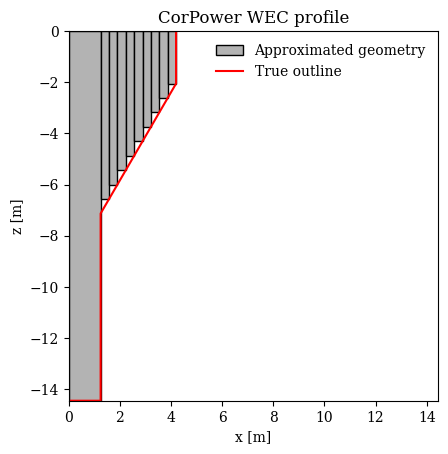

In [10]:
dataset = compute_CorPower_data(r1,r2,d1,d2,d3,omegas,rho,g,h,show_geom=True,save_data=True)

In [11]:
np.array([12.1])[:,None]

array([[12.1]])

In [12]:
dataset

<xarray.Dataset> Size: 1kB
Dimensions:                (omega: 10, radiating_dof: 1, influenced_dof: 1,
                            wave_direction: 1)
Coordinates:
  * omega                  (omega) float64 80B 0.4 0.5222 0.6444 ... 1.378 1.5
  * radiating_dof          (radiating_dof) category 9B Heave
  * influenced_dof         (influenced_dof) category 9B Heave
  * wave_direction         (wave_direction) float64 8B 0.0
    g                      float64 8B 9.81
    rho                    int64 8B 1000
    body_name              <U12 48B 'CorPower_WEC'
    water_depth            int64 8B 100
    forward_speed          float64 8B 0.0
    period                 (omega) float64 80B 15.71 12.03 9.75 ... 4.56 4.189
    wavenumber             (omega) float64 80B 0.01736 0.02801 ... 0.1935 0.2294
    wavelength             (omega) float64 80B 362.0 224.4 148.4 ... 32.47 27.39
Data variables:
    added_mass             (omega, radiating_dof, influenced_dof) float64 80B ...
    radiation_damping      (omega, radiating_dof, influenced_dof) float64 80B ...
    diffraction_force      (omega, wave_direction, influenced_dof) complex128 160B ...
    Froude_Krylov_force    (omega, wave_direction, influenced_dof) complex128 160B ...
    excitation_force       (omega, wave_direction, influenced_dof) complex128 160B ...
    inertia_matrix         (radiating_dof, influenced_dof) float64 8B 2.657e+05
    hydrostatic_stiffness  (radiating_dof, influenced_dof) float64 8B 5.436e+05

In [13]:
dataset.hydrostatic_stiffness

<xarray.DataArray 'hydrostatic_stiffness' (radiating_dof: 1, influenced_dof: 1)> Size: 8B
array([[543647.58215547]])
Coordinates:
  * radiating_dof   (radiating_dof) category 9B Heave
  * influenced_dof  (influenced_dof) category 9B Heave
    g               float64 8B 9.81
    rho             int64 8B 1000
    body_name       <U12 48B 'CorPower_WEC'
    water_depth     int64 8B 100
    forward_speed   float64 8B 0.0

In [ ]:
import gmsh, pygmsh
from capytaine.io.meshio import load_from_meshio
r1 = 8.4/2  # top radius [m]
r2 = 2.5/2  # bottom radius [m]
h1 = 4.5  # height of cylindrical portion [m]
h2 = 5.1 # height of slanted portion [m]
h3 = 7.3
float_freeboard = 2.5 # vertical distance above surface [m] 
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    cyl = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    cone = geom.add_cone([0, 0, -h1], [0, 0, -h2], r1, r2)
    cyl2 = geom.add_cylinder([0, 0, -h1-h2], [0, 0, -h3], r2)
    geom.translate(cyl, [0, 0, float_freeboard])
    geom.translate(cone, [0, 0, float_freeboard])
    geom.translate(cyl2, [0, 0, float_freeboard])
    geom.boolean_union([cyl, cone, cyl2])
    mesh_float = geom.generate_mesh()

# lid
mesh_obj = load_from_meshio(mesh_float, 'float')
lid_mesh = mesh_obj.generate_lid(z=-1e-2)

# floating body
CorPower_fb = cpt.FloatingBody(mesh=mesh_obj,
                               lid_mesh=lid_mesh,
                               dofs=cpt.rigid_body_dofs(rotation_center=(0, 0, 0)),
                               center_of_mass=(0, 0, 0),
                               name="CorPower")
CorPower_fb.inertia_matrix = CorPower_fb.compute_rigid_body_inertia()
CorPower_fb.hydrostatic_stiffness = CorPower_fb.immersed_part().compute_hydrostatic_stiffness()



CorPower_fb.center_of_mass = np.array([0.0,0.0,0.0])
CorPower_fb.rotation_center = np.array([0.0,0.0,0.0])
CorPower_fb.add_translation_dof(name='Heave')

# Compute hydrostatics
CorPower_fb = CorPower_fb.keep_immersed_part()
CorPower_fb.hydrostatics = CorPower_fb.compute_hydrostatics(rho=rho,g=g)











fb = cpt.FloatingBody(mesh=mesh,
                      center_of_mass=(0,0,0))
fb.rotation_center = np.array([0,0,0])
fb.add_translation_dof(name="Heave")
fb.inertia_matrix = fb.compute_rigid_body_inertia()
fb.hydrostatic_stiffness = fb.immersed_part().compute_hydrostatic_stiffness()

input_dict = {"omega":np.linspace(2,3,10),
                "wave_direction":[0.0],
                "radiating_dof":["Heave"],
                "water_depth":1000,
                "rho":1000,
                "g":9.81}
test_matrix = xr.Dataset(coords=input_dict)
dataset = cpt.BEMSolver().fill_dataset(test_matrix, fb)


[12:24:14] WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

...

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

           WARNING  The mesh of the body FloatingBody(..., name="cylinder_0") has 240 panels above the free        
                    surface.                                                                                       
                    It has been clipped to fit inside the domain.                                                  
                    To remove this warning, clip the mesh manually with the `immersed_part()` method.

c:\Users\15183\miniconda3\envs\openflash-env\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [15]:
dataset

<xarray.Dataset> Size: 1kB
Dimensions:                (omega: 10, radiating_dof: 1, influenced_dof: 1,
                            wave_direction: 1)
Coordinates: (12/13)
  * omega                  (omega) float64 80B 2.0 2.111 2.222 ... 2.889 3.0
  * radiating_dof          (radiating_dof) category 9B Heave
  * influenced_dof         (influenced_dof) category 9B Heave
  * wave_direction         (wave_direction) float64 8B 0.0
    g                      float64 8B 9.81
    rho                    float64 8B 1e+03
    ...                     ...
    water_depth            float64 8B 1e+03
    forward_speed          float64 8B 0.0
    freq                   (omega) float64 80B 0.3183 0.336 ... 0.4598 0.4775
    period                 (omega) float64 80B 3.142 2.976 2.827 ... 2.175 2.094
    wavenumber             (omega) float64 80B 0.4077 0.4543 ... 0.8507 0.9174
    wavelength             (omega) float64 80B 15.41 13.83 12.48 ... 7.386 6.849
Data variables:
    added_mass             (omega, radiating_dof, influenced_dof) float64 80B ...
    radiation_damping      (omega, radiating_dof, influenced_dof) float64 80B ...
    diffraction_force      (omega, wave_direction, influenced_dof) complex128 160B ...
    Froude_Krylov_force    (omega, wave_direction, influenced_dof) complex128 160B ...
    excitation_force       (omega, wave_direction, influenced_dof) complex128 160B ...
    inertia_matrix         (influenced_dof, radiating_dof) float64 8B 3.061e+04
    hydrostatic_stiffness  (influenced_dof, radiating_dof) float64 8B 3.003e+04
Attributes: (12/18)
    start_of_computation:                     2026-07-15T12:24:14.344602
    green_function:                           Delhommeau
    tabulation_nr:                            676
    tabulation_rmax:                          100.0
    tabulation_nz:                            372
    tabulation_zmin:                          -251.0
    ...                                       ...
    engine:                                   BasicMatrixEngine
    matrix_cache_size:                        1
    linear_solver:                            lu_decomposition
    method:                                   indirect
    creation_of_dataset:                      2026-07-15T12:24:14.944413
    capytaine_version:                        2.3.1

In [16]:
dataset.inertia_matrix

<xarray.DataArray 'inertia_matrix' (influenced_dof: 1, radiating_dof: 1)> Size: 8B
array([[30614.67458921]])
Coordinates:
  * influenced_dof  (influenced_dof) category 9B Heave
  * radiating_dof   (radiating_dof) category 9B Heave
    g               float64 8B 9.81
    rho             float64 8B 1e+03
    body_name       <U10 40B 'cylinder_0'
    water_depth     float64 8B 1e+03
    forward_speed   float64 8B 0.0

In [17]:
dataset.hydrostatic_stiffness.values

array([[30032.99577201]])

In [19]:
fb.inertia_matrix

<xarray.DataArray 'inertia_matrix' (influenced_dof: 1, radiating_dof: 1)> Size: 8B
array([[30614.67458921]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 20B 'Heave'
  * radiating_dof   (radiating_dof) <U5 20B 'Heave'

In [18]:
# import os
# input_data_dir = os.path.dirname(__file__)
# output_dir = os.path.join(input_data_dir, 'outputs')
# cpt.export_dataset(os.path.join(output_dir, 'cpt_hydrodynamics.nc'), dataset)
# cpt.io.legacy.export_hydrostatics_from_dataset(output_dir, cpt_hydrostatics)
# export_hydrostatics(output_dir, [float_body, spar_body])